# Модуль 3. Метрики при дисбалансе: ROC-AUC против PR-AUC

**Длительность:** 90 минут
**Формат:** теория (65 мин) + практика (25 мин)
**Цель модуля:** Учащийся должен понять структурную причину, по которой ROC-AUC может показывать обманчиво высокое значение при сильном дисбалансе классов, освоить механику построения Precision-Recall кривой и научиться обоснованно выбирать между ROC-AUC и PR-AUC в зависимости от соотношения классов в задаче.

## 1. Введение: постановка проблемы (5 мин)

### 1.1. Откуда берется вопрос
В Модуле 2 мы определили ROC-AUC как вероятность того, что случайный positive объект получит более высокий скор, чем случайный negative объект, и отметили, что эта метрика не зависит от выбора порога — удобное свойство для сравнения моделей. Там же было дано предупреждение: при сильном дисбалансе классов ROC-AUC может вводить в заблуждение. Этот модуль разбирает **механизм** этого искажения на уровне формул, а не просто декларирует факт.

### 1.2. Формулировка проблемы
Рассмотрим задачу с крайним дисбалансом: 1 positive объект на 10 000 negative (типичная ситуация в антифроде, детекции редких заболеваний, детекции аномалий). Возможна ситуация, при которой модель демонстрирует ROC-AUC = 0.98 — число, которое обычно интерпретируется как «отличная модель» — при этом на практике модель генерирует настолько много ложных срабатываний относительно числа найденных positive объектов, что её применение в проде бессмысленно: аналитики захлебываются в ложных тревогах. Нужно понять, почему так происходит, и какая метрика не даст себя обмануть в такой ситуации.

## 2. Повторение FPR и эффект «растворения» ложных срабатываний (15 мин)

### 2.1. Формула FPR
$$FPR = \frac{FP}{FP + TN}$$

Знаменатель — это **все реальные negative объекты** в выборке (найденные правильно, TN, и ошибочно помеченные как positive, FP).

### 2.2. Что происходит при сильном дисбалансе
Если negative класс составляет подавляющее большинство выборки, то при любом разумном пороге TN — очень большое число, зачастую на несколько порядков больше, чем FP. В этом случае:
$$FPR = \frac{FP}{FP + TN} \approx \frac{FP}{TN} \quad \text{при } TN \gg FP$$

Это означает, что даже значительное **абсолютное** количество ложных срабатываний дает крошечное **относительное** значение FPR, потому что оно делится на огромное число TN.

### 2.3. Числовой пример
Выборка: 100 000 объектов, из них 100 positive (0.1 %, дисбаланс примерно 1:1000), 99 900 negative.

Модель на некотором пороге дает: TP = 80, FN = 20 (значит Recall = 0.80), FP = 500, TN = 99 400.

Проверка тождеств: TP + FN = 80 + 20 = 100 = P (весь positive класс). FP + TN = 500 + 99 400 = 99 900 = N (весь negative класс). Оба совпадают с исходными числами — разложение корректно.

Посчитаем FPR:
$$FPR = \frac{500}{500 + 99\,400} = \frac{500}{99\,900} \approx 0.00501$$

**FPR ≈ 0.5 %.** Несмотря на то что модель ошибочно пометила 500 нормальных объектов как positive, относительно почти 100-тысячного пула negative объектов эта ошибка практически незаметна.

### 2.4. Что при этом происходит с Precision
Formula Precision не содержит TN вообще:
$$\text{Precision} = \frac{TP}{TP + FP} = \frac{80}{80 + 500} = \frac{80}{580} \approx 0.138$$

**Precision ≈ 13.8 %.** Из каждых 100 срабатываний модели только около 14 — реальные positive, 86 — ложные тревоги. Огромная разница в восприятии одной и той же ситуации: FPR говорит «почти идеально» (0.5 % ошибок), Precision говорит «модель ошибается в 86 % случаев, когда бьет тревогу».

### 2.5. Суть эффекта
Формально это называют эффектом **«растворения» (dilution)** ложных срабатываний: одно и то же абсолютное число FP оказывает почти незаметное влияние на FPR (потому что знаменатель — весь огромный negative класс), но оказывает прямое, ничем не смягченное влияние на Precision (потому что знаменатель — это только positive-предсказания модели, число которых сопоставимо по порядку с самим FP). Это не ошибка ROC-AUC как метрики — это её структурное свойство, которое становится проблемой конкретно тогда, когда потребитель метрики интересуется не «умеет ли модель ранжировать», а «сколько ложных тревог обрушится на оператора».

## 3. Почему ROC-AUC вводит в заблуждение при дисбалансе (15 мин)

### 3.1. От одной точки к всей кривой
В разделе 2 разобрана одна точка ROC-кривой — при одном конкретном пороге. Но эффект «растворения» действует практически на всем диапазоне разумных порогов, а не только в выбранной точке: для любого threshold, при котором FP остается на порядок или два меньше TN (что выполняется почти всегда при дисбалансе 1:1000 и сильнее, кроме экстремально низких порогов), FPR остается малым.

Следствие: ROC-кривая при сильном дисбалансе почти неизбежно проходит близко к идеальному левому верхнему углу $(0, 1)$ на большей части своей длины, даже если абсолютное число ложных срабатываний модели велико. Площадь под такой кривой (ROC-AUC) получается высокой — 0.90–0.99 — независимо от того, насколько «шумной» окажется работа модели в терминах реальных операционных издержек.

### 3.2. Визуализация эффекта: что «растворяется»
Представим ROC-кривую как график, где ось X (FPR) сжата эффектом деления на огромный $TN$. Модель, генерирующая тысячи ложных срабатываний, на этой сжатой оси выглядит так, будто она почти не ошибается — потому что масштаб оси X устроен так, что «тысячи FP» и «ноль FP» визуально почти неотличимы, если $TN$ имеет порядок сотен тысяч или миллионов.

Precision-Recall кривая (раздел 4) использует другую ось — Recall вместо FPR по X, и Precision вместо TPR по Y, — и именно замена FPR на Precision убирает эффект сжатия, потому что Precision не делится на TN.

### 3.3. Итоговая формулировка проблемы
**ROC-AUC отвечает на вопрос: «Насколько хорошо модель в принципе ранжирует positive объекты выше negative?»** Это вопрос об **относительном** порядке скоров внутри каждого класса, и для него не важно, сколько всего negative объектов в системе — важна лишь их упорядоченность относительно positive.

**Precision (и, соответственно, PR-AUC) отвечает на другой вопрос: «Если я подниму тревогу по каждому positive предсказанию модели, какая доля этих тревог окажется верной?»** Это вопрос об **абсолютной цене ошибки** в контексте того, сколько объектов реально проходит через фильтр модели — и здесь дисбаланс классов имеет решающее значение, потому что даже небольшая относительно $N$ доля ложных срабатываний может в абсолютных числах многократно превышать TP.

Оба вопроса законны, но при сильном дисбалансе и практическом интересе к операционной нагрузке (сколько ложных тревог получит оператор/аналитик/врач) второй вопрос — единственный релевантный, а первый систематически создает иллюзию благополучия.

## 4. Precision-Recall кривая (15 мин)

### 4.1. Определение осей
- **Ось X: Recall** — та же величина, что TPR из Модуля 2: $Recall = \dfrac{TP}{TP+FN}$.
- **Ось Y: Precision**: $Precision = \dfrac{TP}{TP+FP}$.

PR-кривая — это график зависимости Precision от Recall при переборе порога классификации, построенный по той же общей механике перебора порогов, что и ROC-кривая в Модуле 2 (раздел 7.3): для каждого порога $t$ вычисляем TP, FP, FN при данном пороге, из них — Recall и Precision, получаем точку.

### 4.2. Почему замена оси меняет всё
Ключевое структурное отличие от ROC: **ни одна из двух осей PR-кривой не содержит TN**. Обе оси — Recall и Precision — построены исключительно из TP, FP, FN. Именно поэтому PR-кривая не подвержена эффекту «растворения» из раздела 2: рост FP напрямую снижает Precision независимо от того, насколько велик $TN$.

### 4.3. Граничные точки PR-кривой
- **При максимально строгом пороге** (например, $t=1$, ни один объект не предсказан positive): $TP = 0$, $FP = 0$, значит $Recall = 0/(0+P) = 0$. Precision же формально не определена — деление $0/0$ ($TP+FP=0$). По общепринятой конвенции (в том числе в `sklearn.metrics.precision_recall_curve`) в этой точке Precision полагается равной **1** — это техническая договоренность для замыкания кривой, а не результат вычисления по формуле.
- **При максимально мягком пороге** ($t=0$, все объекты предсказаны positive): $FN = 0 \Rightarrow Recall = 1$. При этом $TP + FP$ — это весь датасет, а $TP$ — все реальные positive объекты, поэтому:
$$Precision = \frac{TP}{TP+FP} = \frac{P}{P+N} = \text{prevalence}$$
то есть Precision в этой точке равен **доле positive класса во всей выборке** — этот момент станет центральным в разделе 5.

### 4.4. Сравнение граничных точек ROC и PR

| | ROC-кривая | PR-кривая |
|---|---|---|
| Точка при строгом пороге | $(0, 0)$ — всегда | $(Recall=0,\ Precision=1)$ — по конвенции |
| Точка при мягком пороге | $(1, 1)$ — всегда | $(Recall=1,\ Precision=\text{prevalence})$ — зависит от данных |

Это принципиальное различие: **правый конец ROC-кривой не зависит от баланса классов, а правый конец PR-кривой зависит напрямую**. Именно в этом формальный источник того, что PR-кривая «чувствует» дисбаланс, а ROC-кривая — структурно нет.

### 4.5. Форма PR-кривой, в отличие от ROC, не монотонна
ROC-кривая монотонно не убывает по обеим осям при движении от строгого порога к мягкому (TPR и FPR только растут). PR-кривая такой гарантии не дает: Precision может как расти, так и падать немонотонно при снижении порога, потому что добавление новых positive-предсказаний может временно улучшать или ухудшать долю верных среди них в зависимости от того, как распределены скоры объектов. Из-за этого PR-кривые на практике часто выглядят «зубчатыми», особенно на небольших выборках.

## 5. PR-AUC: интерпретация и базовая линия (10 мин)

### 5.1. Определение
**PR-AUC** — площадь под Precision-Recall кривой. На практике в Scikit-Learn чаще используется близкая величина — **Average Precision (AP)**:
$$AP = \sum_n (R_n - R_{n-1}) \cdot P_n$$
где сумма берется по точкам кривой, отсортированным по возрастанию Recall. Это взвешенная сумма точечных значений Precision (правило прямоугольников), а не трапециевидное интегрирование.

### 5.2. Почему не трапециевидное правило
Для ROC-кривой корректно линейно интерполировать между двумя достижимыми точками: классификатор, случайно выбирающий между двумя порогами с некоторой вероятностью, реализует любую точку на отрезке между ними в ROC-пространстве — то есть интерполяция физически достижима, и трапециевидная площадь честна.

Для PR-кривой это свойство не выполняется: точка на прямой между двумя достижимыми PR-точками, как правило, **не** соответствует никакому реальному классификатору или их вероятностной смеси. Линейная интерполяция в PR-пространстве систематически завышает достижимую площадь. Поэтому `average_precision_score` в sklearn использует ступенчатую формулу (5.1) вместо `np.trapz` по сырым точкам кривой — это единственный корректный способ оценить площадь, не создавая иллюзию недостижимого качества.

### 5.3. Базовая линия: почему не 0.5
Для ROC-AUC базовая линия случайного классификатора — **всегда 0.5**, независимо от баланса классов (раздел 7.5 Модуля 2). Для PR-AUC это не так.

Рассмотрим классификатор, присваивающий скор случайно и независимо от истинной метки («no-skill classifier»). При любом пороге предсказанное positive-множество — это случайное подмножество всей выборки. В среднем доля реальных positive объектов внутри случайного подмножества равна доле positive объектов во всей выборке — то есть **prevalence**, независимо от размера подмножества (от того, какой Recall мы рассматриваем).

Следствие: **PR-кривая случайного классификатора — это не диагональ, а горизонтальная линия на уровне $y = \text{prevalence}$.**

$$\text{PR-AUC}_{\text{random}} \approx \text{prevalence} = \frac{P}{P+N}$$

### 5.4. Практическое следствие для интерпретации чисел
При dисбалансе 1:10 000 (prevalence = 0.0001) значение PR-AUC = 0.3 — это **выдающийся** результат: модель в 3000 раз лучше случайного угадывания в терминах этой метрики. То же самое значение 0.3 для сбалансированной задачи (prevalence = 0.5) означало бы модель хуже случайной. **Число PR-AUC невозможно интерпретировать в отрыве от prevalence конкретного датасета** — в отличие от ROC-AUC, где 0.5 всегда означает «случайно» независимо от баланса классов.

## 6. Когда использовать ROC-AUC, а когда PR-AUC (10 мин)

### 6.1. Сводная таблица

| Критерий | ROC-AUC | PR-AUC |
|---|---|---|
| Оси кривой | FPR (X), TPR (Y) | Recall (X), Precision (Y) |
| Используется TN | Да (в FPR) | Нет |
| Базовая линия случайного классификатора | Всегда 0.5 | Равна prevalence, зависит от данных |
| Чувствительность к дисбалансу классов | Низкая — TN «растворяет» FP | Высокая — Precision напрямую реагирует на FP |
| Интерпретация значения без контекста датасета | Возможна (0.5 = случайно всегда) | Невозможна — нужно знать prevalence |
| Когда предпочтителен | Классы сбалансированы или умеренно смещены; интересует общая ранжирующая способность модели | Сильный дисбаланс, важна цена ложных срабатываний (нагрузка на оператора, доверие к алертам) |

### 6.2. Практическое правило
- Если доля positive класса выше примерно 20–30 %, ROC-AUC остается достаточно информативной и удобной метрикой — эффект «растворения» из раздела 2 еще не доминирует.
- Если доля positive класса заметно ниже (единицы процентов и меньше — типично для фрода, редких заболеваний, дефектов производства), PR-AUC — единственная метрика, которая честно отражает операционное качество модели. ROC-AUC в этой ситуации можно оставить как вспомогательную (например, для отслеживания общей ранжирующей способности между итерациями модели), но не как решающую при принятии бизнес-решений.

### 6.3. Важная оговорка
Обе кривые строятся по одним и тем же исходным вероятностям модели — они не противоречат друг другу и не измеряют «разные модели». Существует теоретический результат (Davis, Goadrich, 2006): если один классификатор строго доминирует над другим на всем ROC-пространстве, он строго доминирует над ним и на всем PR-пространстве для того же датасета, и наоборот. То есть **относительное** ранжирование моделей по двум метрикам, как правило, согласовано — расходится не порядок моделей, а **восприятие абсолютного уровня качества**, что и является главной практической ловушкой ROC-AUC при дисбалансе.

## 7. Практика: 1:10 000 — ROC-AUC против PR-AUC на одном экране (20 мин)

### 7.1. Постановка задачи
Сгенерировать синтетическую выборку с дисбалансом примерно 1:10 000, обучить базовый классификатор, вывести ROC-кривую и PR-кривую рядом на одном рисунке. Визуально убедиться: ROC-кривая почти идеальна, PR-кривая — заметно хуже и честно показывает реальную сложность задачи.

### 7.2. Код

Всего объектов: 500000
Positive (класс 1): 50 (0.01000%)
Negative (класс 0): 499950 (99.99000%)


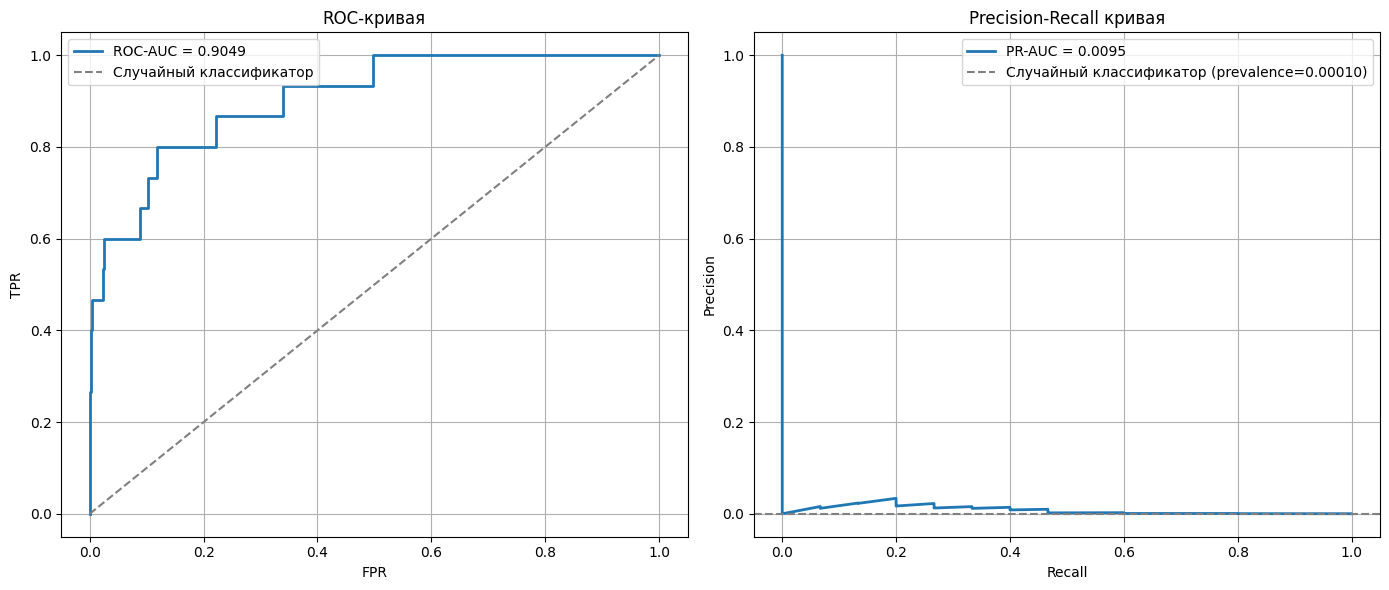


ROC-AUC:                    0.9049
PR-AUC (average precision): 0.0095
Prevalence (базовая линия PR): 0.00010


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# 1. Генерация выборки с дисбалансом ~1:10000
X, y = make_classification(
    n_samples=500_000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    weights=[0.9999, 0.0001],   # ~1 positive на 10000 negative
    flip_y=0,                    # без шума в метках — дисбаланс точный
    random_state=42
)

print(f"Всего объектов: {len(y)}")
print(f"Positive (класс 1): {y.sum()} ({y.mean():.5%})")
print(f"Negative (класс 0): {(1 - y).sum()} ({(1 - y).mean():.5%})")

# 2. Разбиение со стратификацией (обязательно — см. Модуль 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Обучение базового классификатора
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

# 4. ROC-кривая и ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# 5. Precision-Recall кривая и PR-AUC (average precision)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

prevalence = y_test.mean()  # базовая линия для PR-кривой (раздел 5.3)

# 6. Визуализация на одном экране
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Случайный классификатор')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=prevalence, linestyle='--', color='gray',
                 label=f'Случайный классификатор (prevalence={prevalence:.5f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривая')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nROC-AUC:                    {roc_auc:.4f}")
print(f"PR-AUC (average precision): {pr_auc:.4f}")
print(f"Prevalence (базовая линия PR): {prevalence:.5f}")

### 7.3. Что должно получиться
- **ROC-кривая** будет визуально проходить очень близко к точке $(0, 1)$ почти на всей своей длине, а ROC-AUC получится высоким (часто в диапазоне 0.85–0.97 в зависимости от случайного seed и информативности признаков) — то есть будет выглядеть как «отличная модель».
- **PR-кривая** будет заметно ниже и правее по форме, а PR-AUC получится на порядки меньше 1, но при этом на порядки больше prevalence (например, PR-AUC ≈ 0.05–0.20 при prevalence ≈ 0.0001) — это одновременно и честная, и реалистично интерпретируемая картина: модель существенно лучше случайной, но применение её предсказаний потребует смириться с заметной долей ложных срабатываний.
- Горизонтальная линия базовой модели на PR-графике будет находиться практически на нуле (на глаз неотличима от оси X при prevalence = 0.0001) — наглядная иллюстрация того, что даже скромное значение PR-AUC — это большой прогресс относительно случайного угадывания.

### 7.4. Что обсудить по результатам
- Один и тот же классификатор, одни и те же вероятности — но две метрики рассказывают качественно разные истории. Это не противоречие, а прямое следствие разных формул (раздел 3.3).
- Если бы решение о том, готова ли модель к продакшену, принималось только по ROC-AUC, естественным выводом было бы «модель отличная, можно внедрять». Решение по PR-AUC заставляет явно оценить: какую Precision мы получим на желаемом уровне Recall, и готов ли бизнес к соответствующему объему ложных тревог (эта оценка формализуется в Модуле 4 через поиск оптимального порога по матрице издержек).
- Полезное упражнение для самопроверки: изменить `weights` на `[0.9, 0.1]` (дисбаланс 1:9) и перезапустить код. Разрыв между ROC-AUC и PR-AUC должен заметно сократиться — это подтверждает, что эффект специфичен именно для **сильного** дисбаланса, а не является общим недостатком ROC-AUC как такового.

## 8. Итоги модуля (5 мин)

### Ключевые тезисы
1. $FPR = FP/(FP+TN)$ при сильном дисбалансе (большой $TN$) слабо реагирует даже на значительный рост $FP$ — эффект «растворения» ложных срабатываний в огромном пуле negative объектов.
2. Precision = $TP/(TP+FP)$ не содержит $TN$ и потому реагирует на рост $FP$ напрямую и пропорционально — без «амортизации».
3. ROC-кривая всегда начинается в $(0,0)$ и заканчивается в $(1,1)$ независимо от баланса классов; правая граница PR-кривой равна prevalence и зависит от данных — это формальный источник разной чувствительности двух кривых к дисбалансу.
4. PR-AUC (Average Precision) считается ступенчатым правилом, а не трапециевидным, потому что линейная интерполяция между PR-точками физически недостижима для реального классификатора.
5. Базовая линия случайного классификатора для ROC-AUC — всегда 0.5; для PR-AUC — она равна prevalence класса и требует контекста для интерпретации любого конкретного значения.
6. При сильном дисбалансе классов (единицы процентов positive и меньше) PR-AUC — единственная метрика, дающая честную картину операционного качества модели; ROC-AUC в этой ситуации может показывать обманчиво высокое значение при абсолютно неприемлемом на практике уровне ложных срабатываний.

### Контрольные вопросы
- Почему $FPR$ структурно нечувствителен к росту $FP$ при большом $TN$, а $Precision$ — чувствителен?
- Что означает точка $(Recall=1,\ Precision=\text{prevalence})$ на PR-кривой и почему её положение зависит от датасета, в отличие от точки $(1,1)$ на ROC-кривой?
- Почему `average_precision_score` не использует трапециевидное интегрирование, в отличие от вычисления ROC-AUC?
- Чему равна базовая линия PR-кривой случайного классификатора и почему PR-AUC = 0.3 может быть как отличным, так и плохим результатом в зависимости от контекста?
- В каком диапазоне баланса классов ROC-AUC остается достаточно надежной метрикой, а когда нужно переходить на PR-AUC?

### Что дальше
В следующем модуле мы разберем, как перейти от метрик качества ранжирования (ROC-AUC, PR-AUC) к конкретному операционному решению — выбору порога классификации, минимизирующего реальные финансовые издержки бизнеса от ошибок FP и FN.